In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time, os, sys

sys.path.append(os.path.abspath("./src"))

from sparse_methods import matricies
from sampling import samp
from integrals_roots import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]

## Sampling 

Take the distribution:

$$p(x) = \frac{1}{Z}e^{-V(x)} $$

Where

$$V(x) = \frac{x^{2}}{10} + \sin(x) + e^{-5x^{2}}, \qquad Z = \int_{-\infty}^{\infty}e^{-V(x)}dx$$

This is the Boltzmann form, which turns any energy function you can evaluate into a density: where $V(x)$ is our energy, low $V$ means high probability, and $Z$ is whatever constant makes the total probability integrate to 1. The quadratic keeps the tails from running away and is what makes $Z$ finite at all.

Since $e^{-x}$ is decreasing, the mode of $p$ sits wherever $V$ is smallest (this is easy to see mathematically, but is also the definition of energy in this instance), so finding the most probable point is thus a minimization problem and not a sampling problem. Both get done below, along with a second sampler that goes through the CDF instead.

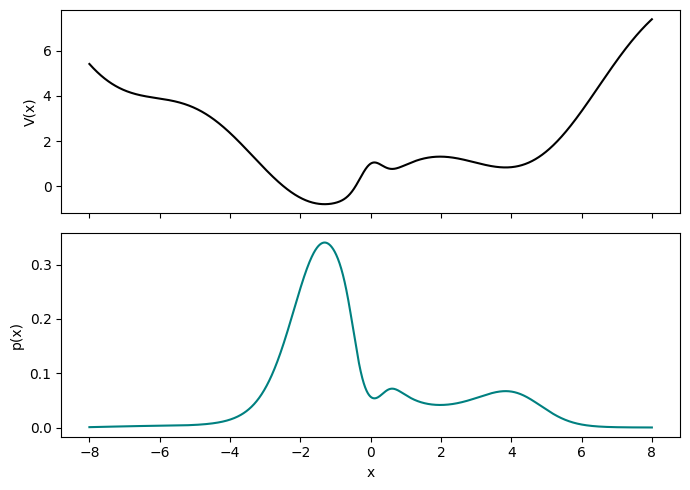

Z = 6.497698


In [3]:
v = lambda x: (
    (x**2 / 10) + (np.sin(x)) + (np.exp(-5*(x**2)))
)

z = integrals.midpoint_area(lambda x: np.exp(-v(x)), -10, 10, 20_000)

p = lambda x: (
    (1 / z) * (np.exp(-v(x)))
)

xs = np.linspace(-8, 8, 2_000)

fig, (top, bottom) = plt.subplots(2, 1, figsize = (7, 5), sharex = True)

top.plot(xs, v(xs), color = "black")
top.set_ylabel("V(x)")

bottom.plot(xs, p(xs), color = "teal")
bottom.set_ylabel("p(x)")
bottom.set_xlabel("x")

plt.tight_layout()
plt.show()

print(f"Z = {z:.6f}")

### Inverse CDF sampling

The naive approach to sample from some probability is to use an inverse cdf: sample from $u \sim U(0, 1)$, then find $x$ such that $\text{cdf}(x) = u$; if $F$ is the CDF of $p$ and $u \sim U(0, 1)$, then $F^{-1}(u) \sim p$, because $F$ maps the distribution onto a uniform by construction. So sample a uniform, solve $F(x) = u$ for $x$, and the result is an independent draw from $p$. $F(x) = u$ can be solved by the bisection routine, integrating at each point.

This method is expensive. One evaluation of $F$ costs 10,000 evaluations of $p$ for integration, one root solve averages eight halvings plus a few more evaluations finding the bracket, and one sample costs one root solve. That is on the order of $10^{5}$ evaluations of $V$, and thus can be increadibly slow.

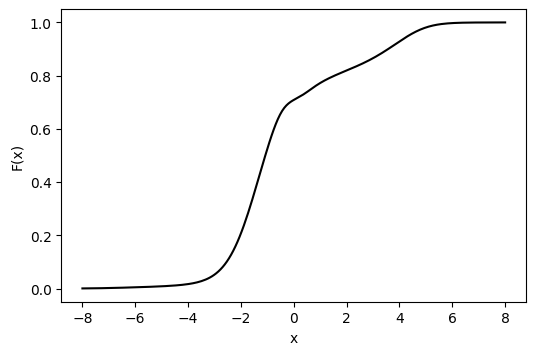

F(x) = 0.1  ->  x =  -2.5383,  check: F(x) = 0.1005
F(x) = 0.5  ->  x =  -1.0769,  check: F(x) = 0.5002
F(x) = 0.9  ->  x =   3.5685,  check: F(x) = 0.8997


In [4]:
cdf_x = np.linspace(-8, 8, 200)
cdf_y = np.array([samp.cdf(t, p) for t in cdf_x])

plt.plot(cdf_x, cdf_y, color = "black")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.show()

for u in (0.1, 0.5, 0.9):
    root = samp.inverse_cdf(u, distribution = p)
    print(f"F(x) = {u}  ->  x = {root:>8.4f},  check: F(x) = {samp.cdf(root, p):.4f}")

1000 samples in 11731.69 ms
sample mean -0.3480, sample std 2.3898


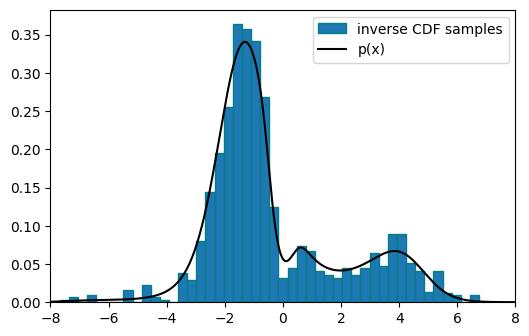

In [5]:
start = time.perf_counter_ns()

cdf_samples = samp.cdf_sampling(distribution = p, n = 10**3)

cdf_time = (time.perf_counter_ns() - start) * 1e-6

print(f"1000 samples in {cdf_time:.2f} ms")
print(f"sample mean {cdf_samples.mean():.4f}, sample std {cdf_samples.std():.4f}")

plt.hist(cdf_samples, bins = 51, density = True, edgecolor = "teal", range = (-8, 8), label = "inverse CDF samples")
plt.plot(xs, p(xs), color = "black", label = "p(x)")
plt.xlim(-8, 8)
plt.legend()
plt.show()

### Metropolis MCMC

 While inverse-cdf sampling is the most obvious approach, and will always be accurate, it has its disadvantages. The issue with this is not only that solving for $x$ almost always requires using a root-finding algorithm, but the cdf itself is almost always the integral of a non-trival function, as it is in this case. This means that for each sample, we need to take the integral of a function using midpoint or some other algorithm. This can get expensive quickly.

Sampling from $p$ uses the same proposal and the same accept step, minus the temperature:

$$\alpha = \min\left(1,\; e^{-\left(V(x') - V(x^{(k)})\right)}\right) = \min\left(1,\; \frac{p(x')}{p(x^{(k)})}\right)$$

Written the second way it is clear what is going on, and also clear why this method is the one everybody uses. The acceptance probability depends on $p$ only through a ratio, so $Z$ cancels out of it. You can sample from a distribution you cannot normalize, which matters enormously in higher dimensions where $Z$ is an integral nobody can do. 

And it doesn't just simulate a similar distribution. Amortized, it actually simulates the exact distribution of $p$. The proof for this is fairly long and complex, but once you understand the intuition, this assumption isn't that large of a logical leap.

The chain that results satisfies detailed balance with respect to $p$, meaning $p$ is its stationary distribution, so after enough steps the states it visits are distributed like $p$ and a histogram of them approximates the density. What you give up is independence: consecutive samples differ by at most one proposal, so they are heavily correlated, and 1000 MCMC samples carry much less information than 1000 independent ones.

The chain starts at $x = 0$, which is not a typical draw from $p$, so the first $m$ samples are pulled toward the start. Discarding even just the first ~20 is enough here given how narrow the distribution is and that the proposal moves on the same scale.

`mcmc_sample` also takes a thinning factor, which keeps only every $j^{th}$ state and throws the rest away. It cuts the correlation between stored samples at $j$ times the runtime. The first run below uses no thinning and $m = 0$, the second uses a thinning factor of 2 and $m = 50$.

1000 samples in 15.94 ms
sample mean -0.6780, sample std 1.9862


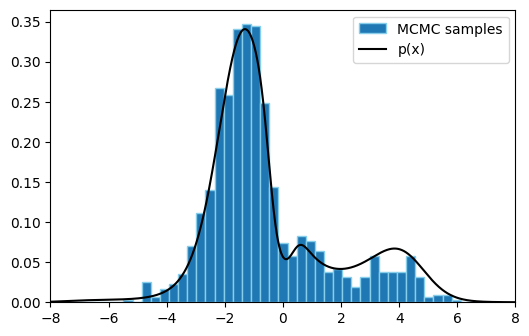

In [ ]:
start = time.perf_counter_ns()

samples = samp.mcmc_sample(v, n = 10**3, m = 0)

mcmc_time = (time.perf_counter_ns() - start) * 1e-6

print(f"1000 samples in {mcmc_time:.2f} ms")
print(f"sample mean {samples.mean():.4f}, sample std {samples.std():.4f}")

plt.hist(samples, bins = 51, density = True, edgecolor = "skyblue", range = (-8, 8), label = "MCMC samples")
plt.plot(xs, p(xs), color = "black", label = "p(x)")
plt.xlim(-8, 8)
plt.legend()
plt.show()

In [ ]:
start = time.perf_counter_ns()

samples = samp.mcmc_sample(v, n = 10**3, m = 50, thining_factor = 2)

mcmc_time = (time.perf_counter_ns() - start) * 1e-6

print(f"1000 samples in {mcmc_time:.2f} ms")
print(f"sample mean {samples.mean():.4f}, sample std {samples.std():.4f}")

plt.hist(samples, bins = 51, density = True, edgecolor = "skyblue", range = (-8, 8), label = "MCMC samples")
plt.plot(xs, p(xs), color = "black", label = "p(x)")
plt.xlim(-8, 8)
plt.legend()
plt.show()

### Comparing the two samplers

Both histograms sit on $p$, so the comparison is about what each one costs and what its samples are worth.

In [7]:
true_mean = integrals.midpoint_area(lambda t: t * p(t), -10, 10, 20_000)

def lag_one(s: np.ndarray) -> float:
    centered = s - s.mean()
    return float((centered[:-1] * centered[1:]).sum() / (centered * centered).sum())

# Effective sample size under the usual AR(1) approximation, n(1 - r) / (1 + r).
# It can come out slightly above n when the measured correlation is negative.
effective = lambda s: len(s) * (1 - lag_one(s)) / (1 + lag_one(s))

print(f"{'':>14} {'runtime (ms)':>14} {'sample mean':>13} {'lag-1 autocorr':>16} {'effective n':>13}")
print(f"{'MCMC':>14} {mcmc_time:>14.2f} {samples.mean():>13.4f} {lag_one(samples):>16.3f} {effective(samples):>13.0f}")
print(f"{'inverse CDF':>14} {cdf_time:>14.2f} {cdf_samples.mean():>13.4f} {lag_one(cdf_samples):>16.3f} {effective(cdf_samples):>13.0f}")
print(f"{'exact':>14} {'':>14} {true_mean:>13.4f}")
print(f"\ninverse CDF is {cdf_time / mcmc_time:.0f}x slower for the same 1000 samples")

                 runtime (ms)   sample mean   lag-1 autocorr   effective n
          MCMC          15.94       -0.6780            0.936            33
   inverse CDF       11731.69       -0.3480            0.009           983
         exact                      -0.3903

inverse CDF is 736x slower for the same 1000 samples


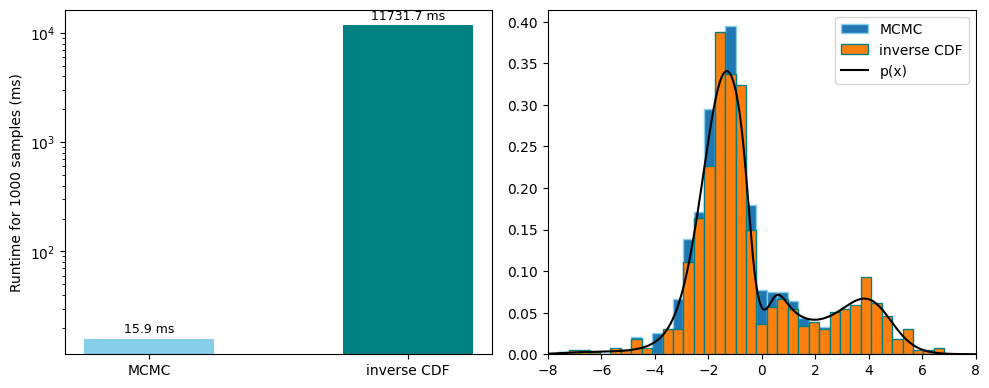

In [8]:
fig, (left, right) = plt.subplots(1, 2, figsize = (10, 4))

left.bar(["MCMC", "inverse CDF"], [mcmc_time, cdf_time], color = ["skyblue", "teal"], width = 0.5)
left.set_yscale("log")
left.set_ylabel("Runtime for 1000 samples (ms)")
left.bar_label(left.containers[0], fmt = "%.1f ms", padding = 2, fontsize = 9)

right.hist(samples, bins = 41, density = True, range = (-8, 8), edgecolor = "skyblue", label = "MCMC")
right.hist(cdf_samples, bins = 41, density = True, range = (-8, 8), edgecolor = "teal", label = "inverse CDF")
right.plot(xs, p(xs), color = "black", label = "p(x)")
right.set_xlim(-8, 8)
right.legend()

plt.tight_layout()
plt.show()

The runtime gap runs to two or three orders of magnitude, and it is not a surprise given the cost stack in the last section. MCMC does one evaluation of $V$ per proposal. Inverse CDF does a full quadrature grid per evaluation of $F$, twenty or so evaluations of $F$ per root solve, and one root solve per sample. Tuning the constants on either side would not change which one wins.

What MCMC pays for that speed is in the last two columns. Its lag-1 autocorrelation runs around $0.94$, meaning consecutive samples are almost the same information, and the usual $n(1 - r)/(1 + r)$ estimate puts the effective size of those 1000 samples at about thirty independent draws. That is the reason its sample mean wanders by a few tenths from run to run against a true mean near $-0.39$, which for 1000 genuine samples of a distribution this narrow would be far too much. The inverse CDF samples are independent by construction, their autocorrelation sits at zero up to noise, all 1000 of them count, and the mean lands closer and stays there.

There are obvious ways to shrink the gap on the slow side. Nothing forces $F$ to be recomputed from scratch for every sample: tabulate it once on a grid, then invert by interpolation, and each additional draw costs a lookup instead of 200,000 function evaluations. In one dimension that would probably make it the better method outright.

None of that helps in higher dimensions, which is where the two stop being interchangeable. There is no CDF to invert in $\mathbb{R}^{d}$, and the quadrature grid behind $Z$ would cost $m^{d}$ points. The Metropolis chain does not care: it needs a proposal and a ratio of densities, and it runs the same way in any number of dimensions. What is implemented here is the one dimensional case of a method built for problems where inversion is not available, so losing a runtime contest to direct inversion in 1D is about what I would expect.